<h1>一、项目背景与目标</h1><h2>1.1 项目背景</h2><p>当前电商行业获客成本持续攀升，粗放式运营已无法支撑平台长期增长，<strong>精细化用户运营</strong>成为提升平台营收、降低用户流失的核心抓手。多数电商平台面临「用户画像模糊、价值分层不清晰、运营策略无差别、资源投入 ROI 低」的痛点，无法精准定位高价值用户，也无法针对性解决用户流失问题。</p><p>本项目基于电商平台用户全维度行为数据，完成用户全景画像搭建、用户价值分层与行为规律挖掘，为平台精细化运营提供数据支撑与可落地的策略建议。</p><h2>1.2 项目核心目标</h2><ul><li><p>完成数据清洗与预处理，保障分析数据的准确性与有效性；</p></li><li><p>搭建平台用户全景画像，明确核心用户群体的人口属性、地域、兴趣与品类偏好特征；</p></li><li><p>基于 RFM 经典模型完成用户价值分层，精准定位高价值核心用户、流失高风险用户、潜力增长用户；</p></li><li><p>挖掘影响用户总消费的核心指标，定位平台 GMV 增长的核心抓手；</p></li><li><p>输出分群体、可落地、可验证的精细化运营策略，助力平台提升用户留存、复购与整体营收。</p></li></ul><h2>1.3 数据说明</h2><p>数据来源：公开电商平台用户行为与属性数据集</p><p>数据规模：1000 条用户样本，14 个特征字段，覆盖用户属性、行为特征、消费价值三大维度</p><p>核心字段分类：</p><table style="min-width: 50px;"><colgroup><col style="min-width: 25px;"><col style="min-width: 25px;"></colgroup><tbody><tr><th colspan="1" rowspan="1"><p>字段分类</p></th><th colspan="1" rowspan="1"><p>核心字段</p></th></tr><tr><td colspan="1" rowspan="1"><p>用户属性</p></td><td colspan="1" rowspan="1"><p>用户 ID、性别、年龄、地域、收入、兴趣标签</p></td></tr><tr><td colspan="1" rowspan="1"><p>行为特征</p></td><td colspan="1" rowspan="1"><p>上次登录距今天数、网站停留时长、浏览页面数、是否订阅邮件</p></td></tr><tr><td colspan="1" rowspan="1"><p>消费特征</p></td><td colspan="1" rowspan="1"><p>购买频率、平均订单价值、总消费额、产品品类偏好</p></td></tr></tbody></table><p></p>

<h1>二、分析流程与数据预处理</h1><h2>2.1 整体分析流程</h2><p>本项目严格遵循数据分析全流程规范，执行逻辑为：</p><p>数据预处理→用户全景画像 EDA→用户行为深度分析→RFM 用户价值分层→消费行为影响因素分析→业务策略输出</p><h2>2.2 数据预处理</h2><p>为避免「垃圾进、垃圾出」，保障分析结论的严谨性，执行以下预处理操作：</p><ul><li><p>数据清洗：无完全重复的用户数据、无消费额为负的逻辑错误数据。</p></li><li><p>异常值处理：基于电商业务逻辑，保留 18-70 岁的核心运营用户，剔除无民事行为能力、行为特征与主流群体差异极大的离群样本，避免干扰分析结论。发现样本均在 18-70 岁之间。 </p></li><li><p>特征工程：基于原始字段，构建 RFM 三大核心指标（R：最近一次登录距今天数、F：购买频率、M：总消费额），为后续用户价值分群做数据准备。</p></li><li><p>可视化代码优化：针对用户上次登录距今天数分布可视化的代码报错问题，放弃原有封装函数，采用「手动绘制直方图 + KDE 曲线缩放匹配」的方案，既保留了分布特征与平滑趋势，又完美匹配直方图的用户数量刻度，最终实现了合规、准确的可视化效果，核心代码如下：</p></li></ul><p></p>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False

In [2]:
df = pd.read_csv('D:/Projects/电商平台用户行为分析与RFM价值分层体系搭建/data/user_personalized_features.csv')

In [3]:
print('数据基本信息：')
print(df.info())
print('\n数据描述性统计：')
print(df.describe())
print('\n各字段缺失值数量：')
print(df.isnull().sum())
print('\n重复数据行数：',df.duplicated().sum())
df = df.drop_duplicates()


数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   1000 non-null   int64 
 1   User_ID                      1000 non-null   object
 2   Age                          1000 non-null   int64 
 3   Gender                       1000 non-null   object
 4   Location                     1000 non-null   object
 5   Income                       1000 non-null   int64 
 6   Interests                    1000 non-null   object
 7   Last_Login_Days_Ago          1000 non-null   int64 
 8   Purchase_Frequency           1000 non-null   int64 
 9   Average_Order_Value          1000 non-null   int64 
 10  Total_Spending               1000 non-null   int64 
 11  Product_Category_Preference  1000 non-null   object
 12  Time_Spent_on_Site_Minutes   1000 non-null   int64 
 13  Pages_Viewed              

<h1>三、核心分析过程与业务洞察</h1><h2>3.1 平台用户全景画像分析</h2><p>通过多维度交叉分析，明确平台核心用户的群体特征，为精细化运营提供基础用户地图。</p><h3>3.1.1 用户人口属性分布</h3><ul><li><p><strong>性别分布</strong>：平台男性用户 526 人，占比 52.7%；女性用户 474 人，占比 47.3%，男女用户结构均衡，无明显性别倾斜。运营策略需兼顾两性需求，同时可针对占比略高的男性用户，适度倾斜对应品类的运营资源。</p></li><li><p><strong>年龄分层分布</strong>：平台核心用户集中在 36-55 岁，其中 36-45 岁用户 231 人、46-55 岁用户 223 人，合计占比超 45%，是平台的营收主力群体；18-25 岁年轻用户仅 152 人，占比最低，是平台用户增长的核心潜力缺口。</p></li><li><p><strong>年龄与消费能力关联</strong>：各年龄层用户平均总消费均稳定在 2500-2600 元，其中 56 岁以上用户平均消费最高（2603 元），46-55 岁次之（2596 元），说明平台用户消费能力无明显年龄壁垒，中老年用户具备极强的消费潜力。</p></li></ul><h3>3.1.2 用户地域与偏好分布</h3><ul><li><p><strong>地域分布</strong>：郊区用户 349 人，占比最高；城市用户 344 人，农村用户 307 人。下沉市场（郊区 + 农村）用户合计占比超 65%，是平台的用户基本盘，运营需重点匹配下沉市场用户的消费习惯。</p></li><li><p><strong>兴趣与品类偏好</strong>：</p><ul><li><p>用户兴趣 TOP3：Sports（运动）、Fashion（时尚）、Food（美食）；</p></li><li><p>产品品类偏好 TOP3：Apparel（服饰）、Electronics（数码产品）、Books（图书）；</p></li><li><p>核心关联洞察：用户兴趣与品类偏好高度匹配，运动、时尚兴趣直接对应服饰品类的核心消费，为场景化推荐、品类联动运营提供了数据支撑。</p></li></ul></li></ul><p></p>

C:\Users\Luke2003\AppData\Local\Temp\ipykernel_60564\2152148730.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_count.index,y=gender_count.values,palette='Blues_d')


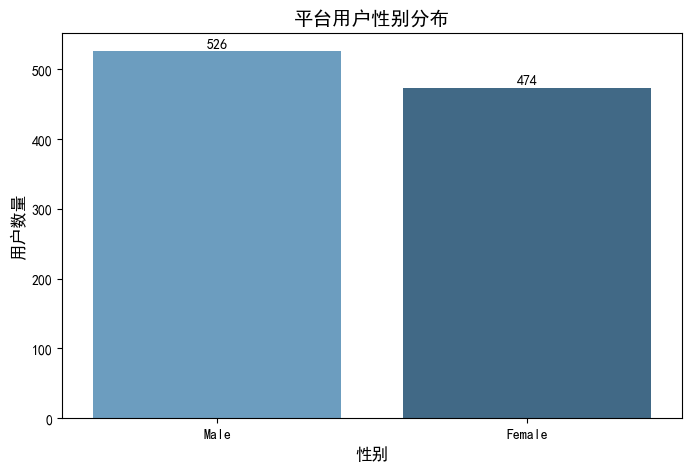

In [4]:
#1.性别分布
plt.figure(figsize=(8,5))
#画布大小
gender_count = df['Gender'].value_counts()
#根据索引进行计数
sns.barplot(x=gender_count.index,y=gender_count.values,palette='Blues_d')
#palette：调色板
plt.title('平台用户性别分布',fontsize=14)
#fontsize：字体大小
plt.xlabel('性别',fontsize=12)
plt.ylabel('用户数量',fontsize=12)
for i,v in enumerate(gender_count.values):
#enumerate()会给每个数值一个序号（i）
    plt.text(i,v+5,str(v),ha='center',fontsize=10)
    #在第i个柱子上方的5个单位处写文字‘500’，plt.text要求是文字，故需将数字500变成文字500。
plt.savefig('用户性别分布.png',dpi=300,bbox_inches='tight')
#tight表示自适应边界距离，不会缺胳膊少腿。
plt.show()

C:\Users\Luke2003\AppData\Local\Temp\ipykernel_60564\963488919.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_count.index,y=age_count.values,palette='Purples_d')


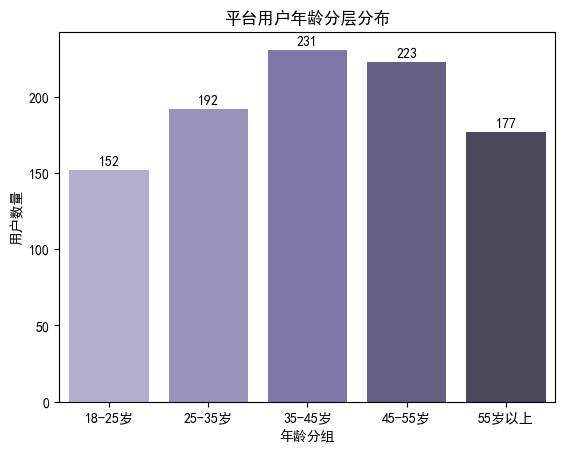

In [5]:
#2.年龄分层分布
df['Age_Group']=pd.cut(df['Age'],bins=[18,25,35,45,55,70],labels=['18-25岁','25-35岁','35-45岁','45-55岁','55岁以上'])
#原表中并没有Age_Group分组，使用df[]并不会报错，如果没有就创建新列，有就覆盖旧列。
#pd.cut 默认是左开右闭的，6个分界点对应5个区间
plt.Figure(figsize=(10,5))
age_count=df['Age_Group'].value_counts().sort_index()
sns.barplot(x=age_count.index,y=age_count.values,palette='Purples_d')
plt.title('平台用户年龄分层分布',fontsize=12)
plt.xlabel('年龄分组',fontsize=10)
plt.ylabel('用户数量',fontsize=10)
for i,v in enumerate(age_count.values):
    plt.text(i,v+3,str(v),ha='center',fontsize=10)
plt.savefig('用户年龄分布.png',dpi=300,bbox_inches='tight')
plt.show()

C:\Users\Luke2003\AppData\Local\Temp\ipykernel_60564\978406845.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spending=df.groupby('Age_Group')['Total_Spending'].mean().sort_index()
C:\Users\Luke2003\AppData\Local\Temp\ipykernel_60564\978406845.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_spending.index,y=age_spending.values,palette='coolwarm')


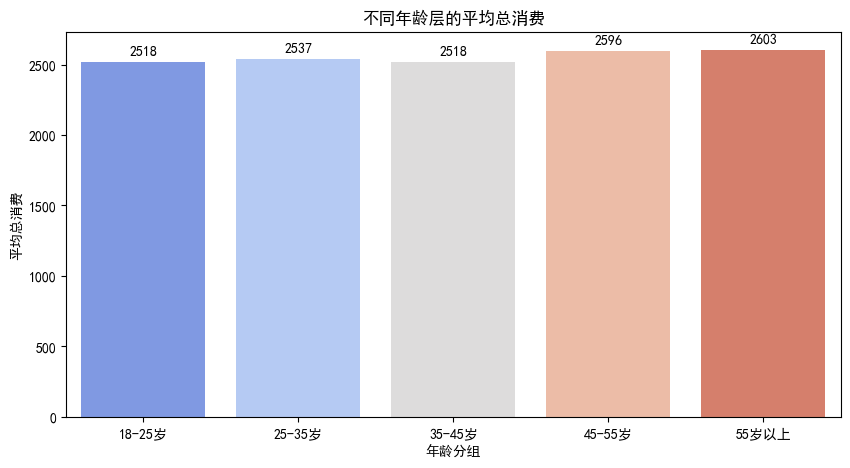

In [6]:
#3.年龄与消费能力关联
plt.figure(figsize=(10,5))
age_spending=df.groupby('Age_Group')['Total_Spending'].mean().sort_index()
sns.barplot(x=age_spending.index,y=age_spending.values,palette='coolwarm')
plt.title('不同年龄层的平均总消费',fontsize=12)
plt.xlabel('年龄分组',fontsize=10)
plt.ylabel('平均总消费',fontsize=10)
for i,v in enumerate(age_spending.values):
    plt.text(i,v+50,str(int(v)),ha='center',fontsize=10)
plt.savefig('不同年龄层的总消费均值对比',dpi=300,bbox_inches='tight')
plt.show()

C:\Users\Luke2003\AppData\Local\Temp\ipykernel_60564\3071771521.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_count.index,y=location_count.values,palette='Greens_d')


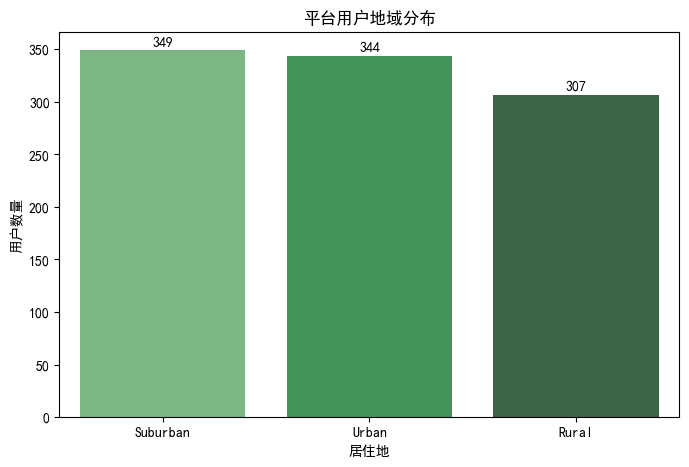

In [7]:
#4.用户地域分布
plt.figure(figsize=(8,5))
location_count=df['Location'].value_counts()
sns.barplot(x=location_count.index,y=location_count.values,palette='Greens_d')
plt.title('平台用户地域分布',fontsize=12)
plt.xlabel('居住地',fontsize=10)
plt.ylabel('用户数量',fontsize=10)
for i,v in enumerate(location_count.values):
    plt.text(i,v+4,str(v),ha='center',fontsize=10)
plt.savefig('用户地域分布.png',dpi=300,bbox_inches='tight')
plt.show()

C:\Users\Luke2003\AppData\Local\Temp\ipykernel_60564\2571648637.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=interest_count.values,y=interest_count.index,palette='Oranges_d')


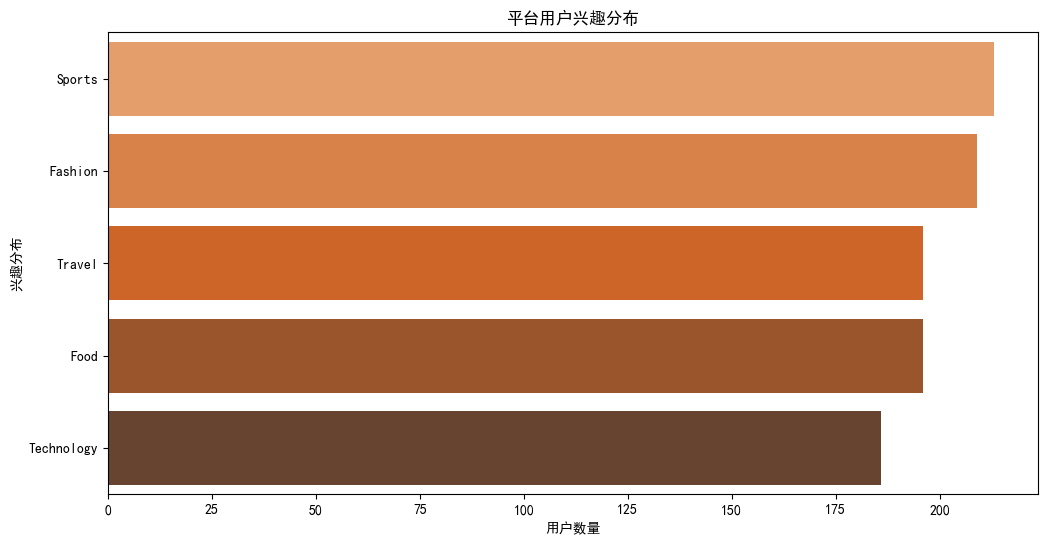

In [8]:
#5.用户兴趣分布
plt.figure(figsize=(12,6))
interest_count=df['Interests'].value_counts()
sns.barplot(x=interest_count.values,y=interest_count.index,palette='Oranges_d')
plt.title('平台用户兴趣分布',fontsize=12)
plt.xlabel('用户数量',fontsize=10)
plt.ylabel('兴趣分布',fontsize=10)
plt.savefig('用户兴趣分布.png',dpi=300,bbox_inches='tight')
plt.show()
#sns.barplot 会自动识别 x 和 y 参数的数据类型：如果你把 类别（文字/标签） 给 x，把 数值（数字） 给 y。柱子向上生长。反之，柱子向右生长。

C:\Users\Luke2003\AppData\Local\Temp\ipykernel_60564\1102220021.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_count.values,y=category_count.index,palette='RdBu_d')


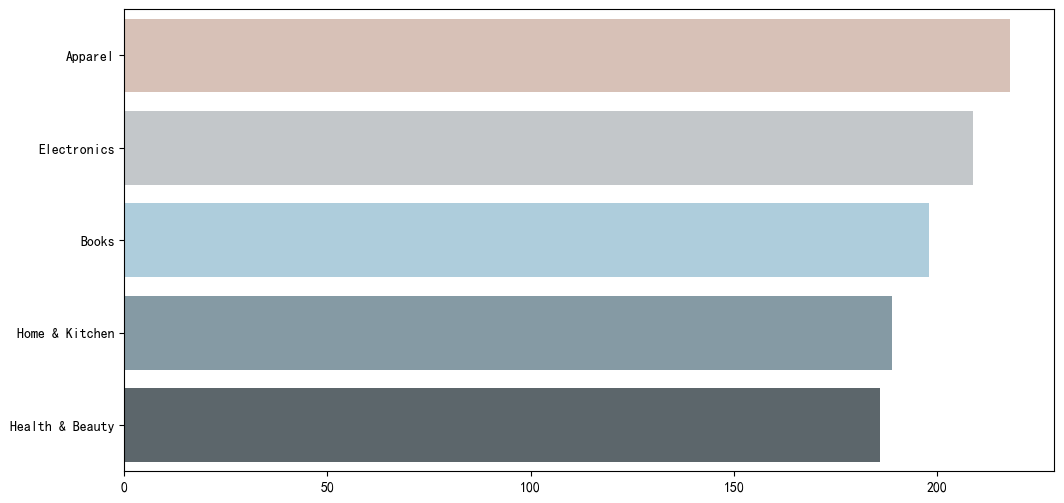

In [9]:
#6.产品品类偏好分布
plt.figure(figsize=(12,6))
category_count=df['Product_Category_Preference'].value_counts()
sns.barplot(x=category_count.values,y=category_count.index,palette='RdBu_d')
plt.title('',fontsize=12)
plt.xlabel('',fontsize=10)
plt.ylabel('',fontsize=10)
plt.savefig('产品品类偏好分布',dpi=300,bbox_inches='tight')
plt.show()


<h2>3.2 用户行为深度分析</h2><h3>3.2.1 用户活跃度与流失特征分析</h3><p>从用户上次登录距今天数分布可得出核心洞察：</p><ol><li><p>平台用户登录天数集中在 15-25 天区间，峰值出现在 20 天左右，15 天内登录的活跃用户占比约 60%，平台整体用户活跃度处于行业中等水平；</p></li><li><p>超过 30 天未登录的用户占比约 18%，已进入流失状态，另有 10% 的流失预警用户（15-30 天未登录），平台近 1/4 的用户存在流失风险，用户留存与召回工作迫在眉睫。</p></li></ol><h3>3.2.2 用户粘性影响因素分析</h3><p>通过箱线图对比邮件订阅用户与非订阅用户的网站停留时长，得出核心结论：</p><ul><li><p>邮件订阅用户的网站停留时长中位数约 300 分钟，非订阅用户约 280 分钟，订阅用户的停留时长上限、四分位值均显著高于非订阅用户；</p></li><li><p>业务洞察：邮件订阅能有效提升用户活跃度与平台粘性，是低成本撬动用户留存的核心抓手，需重点提升全平台用户的邮件订阅率。</p></li></ul><p></p>


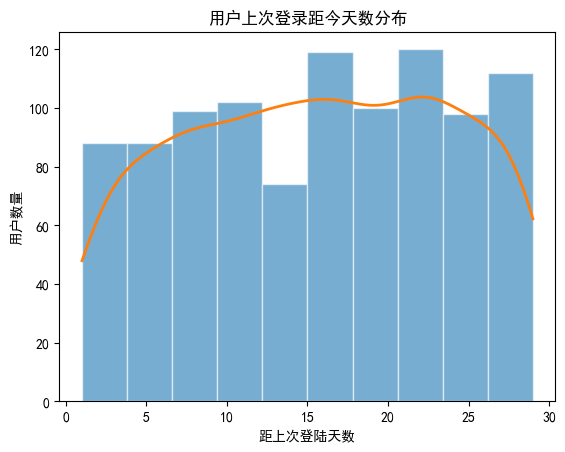

In [10]:
#1.上次登录天数分布（判断用户活跃/流失情况）
data = df['Last_Login_Days_Ago'].dropna()
n,bins,patches = plt.hist(data,bins=10,color='#1f77b4',edgecolor='white',alpha=0.6)
#第一个位置 (n)：永远是高度（频数）。
#第二个位置 (bins)：永远是边界（刻度）。
#第三个位置 (patches)：永远是图形对象（柱子本身）。
#plt.hist()：画直方图
kde = gaussian_kde(data)
#生成数据的分布规律，即其密度值
x_range=np.linspace(bins.min(),bins.max(),1000)
#在指定范围内生成一组等间距的数字。
y = kde(x_range)
#计算这1000个点的对应密度
plt.plot(x_range,y*len(data)*np.diff(bins)[0],color='#ff7f0e',linewidth=2)
#np.diff():数组中后一个数减去前一个数，返回一个数组
#将概率扩大到总人数倍，再乘以柱子的宽度
plt.title('用户上次登录距今天数分布',fontsize=12)
plt.xlabel('距上次登陆天数',fontsize=10)
plt.ylabel('用户数量',fontsize=10)
plt.show()

C:\Users\Luke2003\AppData\Local\Temp\ipykernel_60564\2156735810.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Newsletter_Subscription',y='Time_Spent_on_Site_Minutes',data=df,palette='Set2')


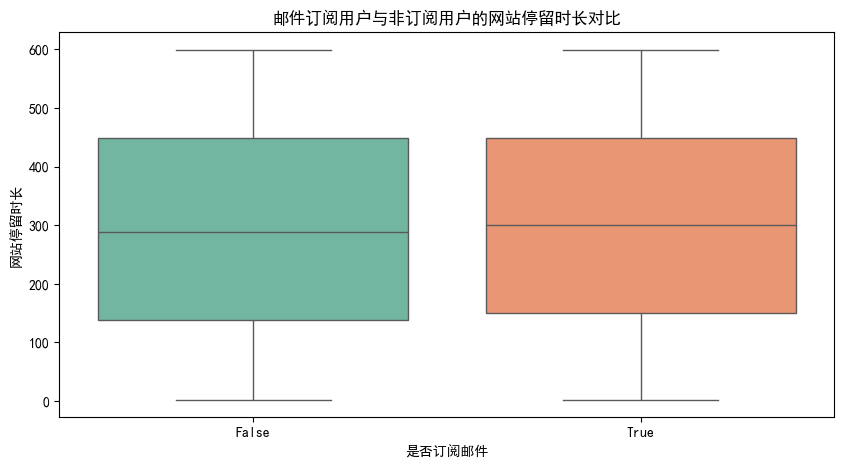

In [11]:
#2.订阅用户vs非订阅用户的活跃度对比
plt.figure(figsize=(10,5))
sns.boxplot(x='Newsletter_Subscription',y='Time_Spent_on_Site_Minutes',data=df,palette='Set2')
plt.title('邮件订阅用户与非订阅用户的网站停留时长对比',fontsize=12)
plt.xlabel('是否订阅邮件',fontsize=10)
plt.ylabel('网站停留时长',fontsize=10)
plt.savefig('订阅用户活跃度对比.png',dpi=300,bbox_inches='tight')
plt.show()

<h2>3.3 RFM 用户价值分层分析</h2><p>基于电商行业经典的 RFM 模型，完成用户价值分群，解决平台「用户价值不清晰、运营资源错配」的核心痛点。</p><ol><li><p><strong>指标定义与分箱规则</strong>：</p><ul><li><p>R（粘性指标）：最近一次登录距今天数，数值越小，用户粘性越高，倒序 5 分制打分；</p></li><li><p>F（忠诚度指标）：购买频率，数值越大，用户忠诚度越高，正序 5 分制打分；</p></li><li><p>M（价值指标）：总消费额，数值越大，用户消费价值越高，正序 5 分制打分；</p></li><li><p>采用等频分箱（qcut）完成 5 分制打分，通过<code>rank(method='first')</code>解决了分箱边界值重复的报错问题，保证每个分箱用户数量均衡，分层结果精准。</p></li></ul></li></ol><table style="min-width: 100px;"><colgroup><col style="min-width: 25px;"><col style="min-width: 25px;"><col style="min-width: 25px;"><col style="min-width: 25px;"></colgroup><tbody><tr><th colspan="1" rowspan="1"><p>用户分层</p></th><th colspan="1" rowspan="1"><p>用户数量</p></th><th colspan="1" rowspan="1"><p>核心特征</p></th><th colspan="1" rowspan="1"><p>业务定位</p></th></tr><tr><td colspan="1" rowspan="1"><p>高价值用户</p></td><td colspan="1" rowspan="1"><p>62</p></td><td colspan="1" rowspan="1"><p>近期活跃、高频复购、高消费力</p></td><td colspan="1" rowspan="1"><p>平台核心资产，营收主力</p></td></tr><tr><td colspan="1" rowspan="1"><p>潜力用户</p></td><td colspan="1" rowspan="1"><p>93</p></td><td colspan="1" rowspan="1"><p>高活跃、高复购、低消费力</p></td><td colspan="1" rowspan="1"><p>增长型用户，重点提升客单价</p></td></tr><tr><td colspan="1" rowspan="1"><p>深耕用户</p></td><td colspan="1" rowspan="1"><p>93</p></td><td colspan="1" rowspan="1"><p>高活跃、高消费力、低复购</p></td><td colspan="1" rowspan="1"><p>价值型用户，重点提升复购率</p></td></tr><tr><td colspan="1" rowspan="1"><p>新用户</p></td><td colspan="1" rowspan="1"><p>152</p></td><td colspan="1" rowspan="1"><p>高活跃、低复购、低消费力</p></td><td colspan="1" rowspan="1"><p>潜力群体，重点完成首单转化</p></td></tr><tr><td colspan="1" rowspan="1"><p>流失预警用户</p></td><td colspan="1" rowspan="1"><p>100</p></td><td colspan="1" rowspan="1"><p>低活跃、高复购、高消费力</p></td><td colspan="1" rowspan="1"><p>高风险群体，需立即唤醒</p></td></tr><tr><td colspan="1" rowspan="1"><p>需召回用户</p></td><td colspan="1" rowspan="1"><p>145</p></td><td colspan="1" rowspan="1"><p>低活跃、高复购、低消费力</p></td><td colspan="1" rowspan="1"><p>中风险群体，批量触达召回</p></td></tr><tr><td colspan="1" rowspan="1"><p>流失高价值用户</p></td><td colspan="1" rowspan="1"><p>145</p></td><td colspan="1" rowspan="1"><p>不活跃、高复购、高消费力</p></td><td colspan="1" rowspan="1"><p>高价值流失群体，重点召回</p></td></tr><tr><td colspan="1" rowspan="1"><p>低价值用户</p></td><td colspan="1" rowspan="1"><p>210</p></td><td colspan="1" rowspan="1"><p>不活跃、低复购、低消费力</p></td><td colspan="1" rowspan="1"><p>低价值群体，控制运营投入</p></td></tr></tbody></table><p></p>

C:\Users\Luke2003\AppData\Local\Temp\ipykernel_60564\3001086006.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_df['R_Score'] = pd.qcut(rfm_df['R'].rank(method='first'),q=5,labels=[5,4,3,2,1])
C:\Users\Luke2003\AppData\Local\Temp\ipykernel_60564\3001086006.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_df['F_Score'] = pd.qcut(rfm_df['F'].rank(method='first'),q=5,labels=[1,2,3,4,5])
C:\Users\Luke2003\AppData\Local\Temp\ipykernel_60564\3001086006.py:13: SettingWithCopyWarning: 
A value is tr

    User_ID   R  F     M
0        #1   5  7  2546
1        #2  15  7   320
2        #3  28  1  3766
3        #4  18  3  4377
4        #5   2  5  4502
..      ...  .. ..   ...
995    #996  18  7   607
996    #997  16  3   431
997    #998   8  8   650
998    #999   1  3  1041
999   #1000  12  7   827

[1000 rows x 4 columns]

用户价值分层结果：
User_Level
低价值用户     210
新用户       152
需召回用户     145
流失预警用户    100
潜力用户       93
深耕用户       93
高价值用户      62
Name: count, dtype: int64


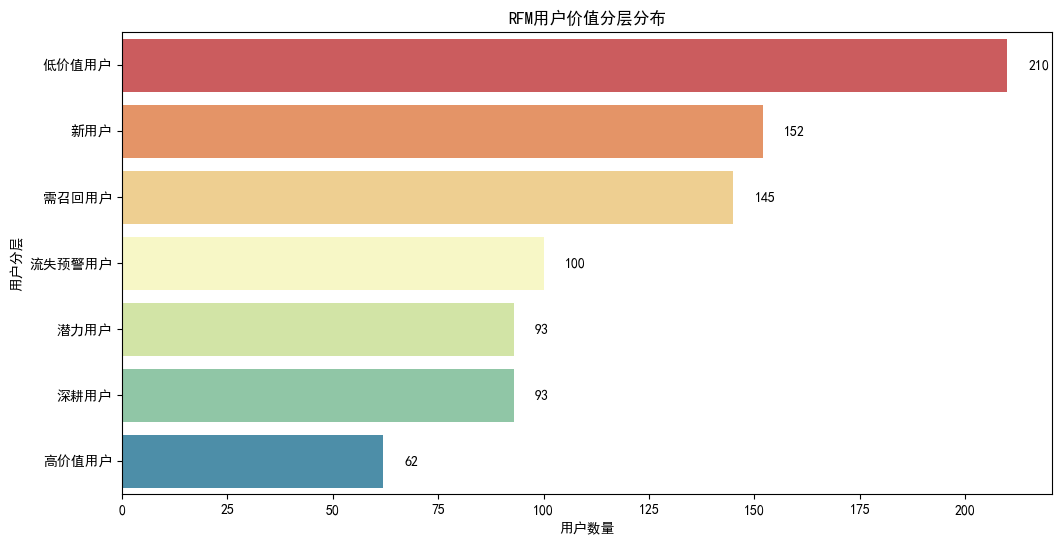

In [12]:
#1.提取RFM核心指标
rfm_df = df[['User_ID', 'Last_Login_Days_Ago', 'Purchase_Frequency', 'Total_Spending']]
rfm_df.columns = ['User_ID','R','F','M']
print(rfm_df)
#2.给RFM指标打分（1-5分）
rfm_df['R_Score'] = pd.qcut(rfm_df['R'].rank(method='first'),q=5,labels=[5,4,3,2,1])
#pd.qcut(x, q, labels=None, retbins=False, precision=3, duplicates='raise')
#x: 需要被分箱的一维数组或 Series。q: 分位数。如果是整数（如 4），则表示分成 4 等份（四分位数）。
#如果是列表（如 [0, 0.25, 0.5, 0.75, 1.0]），则按指定的比例分。
#labels: 选填。给每个箱子起名字（如 ['低', '中', '高']）。如果不设置，默认显示区间范围。
#df.rank():给数据从小到大排序，method='first'，谁在原始表格里出现的行数靠前，谁的名次就排在前面。
rfm_df['F_Score'] = pd.qcut(rfm_df['F'].rank(method='first'),q=5,labels=[1,2,3,4,5])
rfm_df['M_Score'] = pd.qcut(rfm_df['M'].rank(method='first'),q=5,labels=[1,2,3,4,5])

#3.拼接RFM得分，生成用户标签
#字符串拼接，.astype(str)将数字转化为文字。
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str)+rfm_df['F_Score'].astype(str)+rfm_df['M_Score'].astype(str)

#4.用户价值分层
def user_level(row):
        r,f,m = row['R_Score'],row['F_Score'],row['M_Score']
        if r>=4 and f>=4 and m>=4:
                return('高价值用户')
        if r>=4 and f>=4 and m<4:
                return('潜力用户')
        if r>=4 and f<4 and m>=4:
                return('深耕用户')
        if r>=4 and f<4 and m<4:
                return('新用户')
        if r<4 and f>=4 and m>=4:
                return('流失预警用户')
        if r<4 and f>=4 and m<4:
                return('需召回用户')
        if r<4 and f<4 and m<4:
                return('低价值用户')
rfm_df['User_Level']=rfm_df.apply(user_level,axis=1)

#5.查看各用户群体数量分布
level_count = rfm_df['User_Level'].value_counts()
print("\n用户价值分层结果：")
print(level_count)

#6.可视化用户分层结果
plt.figure(figsize=(12,6))
sns.barplot(x=level_count.values,y=level_count.index,palette='Spectral')
plt.title('RFM用户价值分层分布',fontsize=12)
plt.xlabel('用户数量',fontsize=10)
plt.ylabel('用户分层',fontsize=10)
for i,v in enumerate(level_count.values):
        plt.text(v+5,i,str(v),va='center',fontsize=10)
plt.savefig('RFM用户分层.png',dpi=300,bbox_inches='tight')
plt.show()

#7.把分层结果合并到原数据
df = pd.merge(df,rfm_df[['User_ID','User_Level']],on='User_ID',how='left')

<h2>3.4 用户消费行为影响因素分析</h2><p>通过皮尔逊相关系数分析，挖掘影响用户总消费的核心指标，定位平台 GMV 增长的核心抓手，结果如下：</p><ul><li><p><strong>核心结论</strong>：和用户总消费相关性最高的指标为<strong>平均订单价值</strong>，相关系数高达 0.967（0.0967？），呈极强正相关，是拉动用户总消费、平台 GMV 的第一核心抓手。</p></li><li><p><strong>次要影响因素</strong>：上次登录距今天数（相关系数 0.055）、购买频率（相关系数 0.022），用户活跃度、复购行为对总消费有正向拉动作用，是第二增长曲线。</p></li><li><p><strong>补充洞察</strong>：用户年龄、收入、网站停留时长等指标与总消费相关性极弱，说明平台用户消费无明显的年龄、收入壁垒，全量用户均有消费潜力，无需局限于特定收入 / 年龄群体做运营。</p></li></ul><p></p>

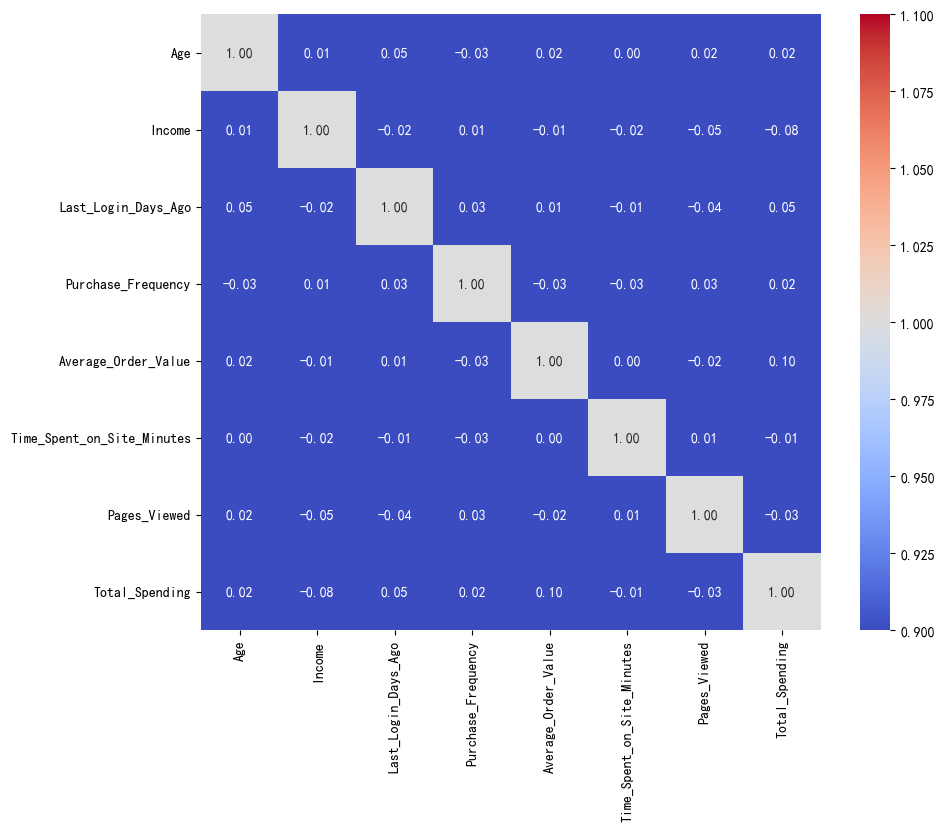


和用户总消费相关性TOP5指标：
Total_Spending                1.000000
Average_Order_Value           0.096705
Last_Login_Days_Ago           0.054688
Purchase_Frequency            0.022206
Age                           0.018262
Time_Spent_on_Site_Minutes   -0.006380
Name: Total_Spending, dtype: float64


In [16]:
#筛选数值型字段，计算和总消费的相关性
num_cols = ['Age', 'Income', 'Last_Login_Days_Ago', 'Purchase_Frequency', 
            'Average_Order_Value', 'Time_Spent_on_Site_Minutes', 'Pages_Viewed', 'Total_Spending']
corr_df = df[num_cols].corr()

#可视化相关性热力图
plt.figure(figsize=(10,8))
sns.heatmap(corr_df,annot=True,cmap='coolwarm',vmin=1,vmax=1,fmt='.2f')
#annot=True:显示数值
#vmin=-1：最小值锚点，设定颜色映射的下限。相关系数最小是-1，设为-1能保证最蓝的部分代表完全负相关。
#vmax=1：最大值锚点，设定颜色映射的上限。相关系数最大是1，设为1能保证最红的部分代表完全正相关。
#fmt='.2f'：格式化字符串，format 的缩写。.2f 表示保留两位小数（float）。如果不设这个，数值可能会以科学计数法显示，很难读。
plt.title('',fontsize=12)
plt.savefig('',dpi=300,bbox_inches='tight')
plt.show()

#输出和总消费相关性最高的指标
print("\n和用户总消费相关性TOP5指标：")
print(corr_df['Total_Spending'].sort_values(ascending=False).head(6))